In [4]:
!pip install tensorflow pandas matplotlib


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached tensorflow-2.18.0-cp312-cp312-win_amd64.whl.metadata (3.3 kB)
  Using cached matplotlib-3.10.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached tensorflow_intel-2.18.0-cp312-cp312-win_amd64.whl.metadata (4.9 kB)
  Using cached absl_py-2.1.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-24.12.23-py2.py3-none-any.whl.metadata (876 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-5.29.3-cp310-abi3-win_amd64.whl.metadata (592 bytes)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached setuptools-75.8.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached termcolor-2.5.0-py3-none-any.whl.metadata (6.1 k

In [1]:
import tensorflow as tf
import cv2
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import imghdr
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

In [2]:
print(tf.config.list_physical_devices('GPU'))

[]


In [3]:
data_dir = 'data'
image_extensions = ['jpeg','jpg','bmp','png']

In [5]:
os.listdir('data')
# list the files in the data directory that are present the same directory as this file

['kitties', 'puppies']

In [6]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir, image_class)):
        image_path = os.path.join(data_dir, image_class, image)
        try:
            img = cv2.imread(image_path)
            ext = imghdr.what(image_path)
            if ext not in image_extensions:
                print('image not in extension list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('issue with image {}'.format(image_path))

image not in extension list data\kitties\GettyImages-480615728.jpg
image not in extension list data\kitties\Un-chat-et-un-chien.jpg
image not in extension list data\puppies\main_puppies_1280p-1710959220337.jpg
image not in extension list data\puppies\Puppy-Nutrition-Image-list.png.webp
image not in extension list data\puppies\puppy-shots.jpg
image not in extension list data\puppies\puppy-with-strawberry-toy.jpg
image not in extension list data\puppies\puppy20and20child.jpg.webp


In [7]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 227 files belonging to 2 classes.


In [8]:
data_iterator = data.as_numpy_iterator()

In [9]:
batch = data_iterator.next()

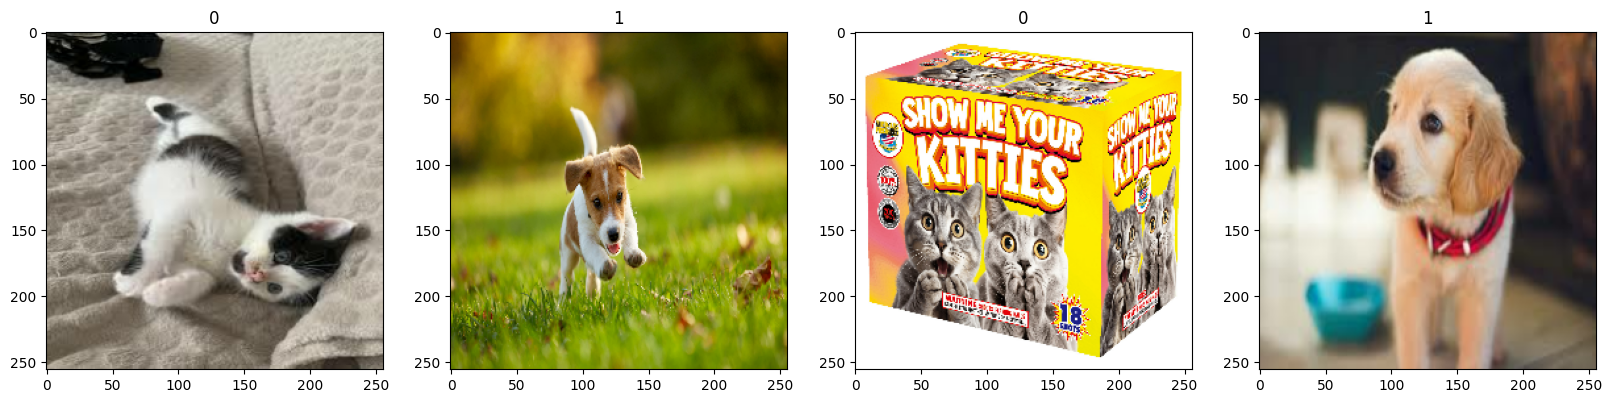

In [10]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [11]:
data = data.map(lambda x,y: (x/255, y))

In [12]:
data.as_numpy_iterator().next()

(array([[[[0.8215533 , 0.7548866 , 0.68040746],
          [0.81578374, 0.7451955 , 0.66316634],
          [0.81376296, 0.74317473, 0.660975  ],
          ...,
          [0.9372549 , 0.8980392 , 0.85882354],
          [0.93524814, 0.89603245, 0.85681677],
          [0.92743564, 0.88821995, 0.84900427]],
 
         [[0.82262456, 0.75524557, 0.6800486 ],
          [0.81658244, 0.74599415, 0.6675628 ],
          [0.8155331 , 0.7449449 , 0.6627451 ],
          ...,
          [0.9372549 , 0.8980392 , 0.85882354],
          [0.93524814, 0.89603245, 0.85681677],
          [0.92743564, 0.88821995, 0.84900427]],
 
         [[0.8274417 , 0.75685346, 0.6784221 ],
          [0.8191842 , 0.7479884 , 0.67137957],
          [0.8167203 , 0.7461321 , 0.6650731 ],
          ...,
          [0.9372549 , 0.8980392 , 0.85882354],
          [0.93524814, 0.89603245, 0.85681677],
          [0.92743564, 0.88821995, 0.84900427]],
 
         ...,
 
         [[0.8898361 , 0.8231694 , 0.7133655 ],
          [0.90986

In [13]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)

In [14]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [15]:
train

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [16]:
model = Sequential()

In [17]:
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())
model.add(Conv2D(32, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(16, (3,3), 1, activation='relu'))
model.add(MaxPooling2D())
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

C:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 14400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       3,686,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
logdir='logs'

In [21]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [22]:
hist = model.fit(train, epochs=20, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.4962 - loss: 1.6513 - val_accuracy: 0.4375 - val_loss: 0.7769
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4181 - loss: 0.7350 - val_accuracy: 0.5625 - val_loss: 0.6872
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 807ms/step - accuracy: 0.5410 - loss: 0.6878 - val_accuracy: 0.6562 - val_loss: 0.6584
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 951ms/step - accuracy: 0.5753 - loss: 0.6695 - val_accuracy: 0.6250 - val_loss: 0.6297
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6021 - loss: 0.6773 - val_accuracy: 0.6875 - val_loss: 0.6122
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 995ms/step - accuracy: 0.7065 - loss: 0.6321 - val_accuracy: 0.7188 - val_loss: 0.5587
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6867 - loss: 0.6053 - val_accuracy: 0.6562 - val_loss: 0.6043
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 945ms/step - accuracy: 0.7089 - loss: 0.5534 - val_accuracy: 0.6875 - val_loss: 0.5936
Epo

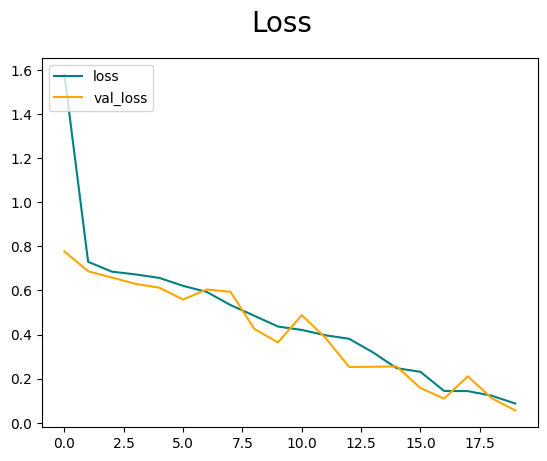

In [23]:
fig = plt.figure()
plt.plot(hist.history['loss'], color='teal', label='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

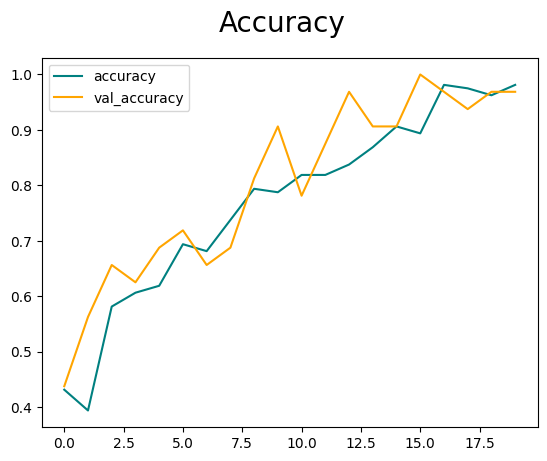

In [24]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [38]:
test

array(<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>,
      dtype=object)

In [44]:
img = cv2.imread(r'C:\Users\Dell\tensoflow\archive\test\cats\cat_1.jpg')

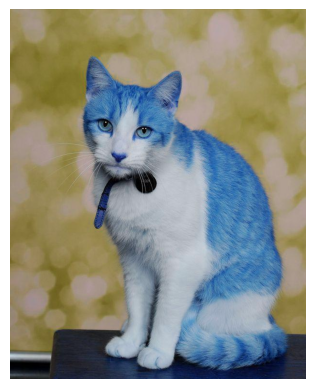

In [46]:
import cv2
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()

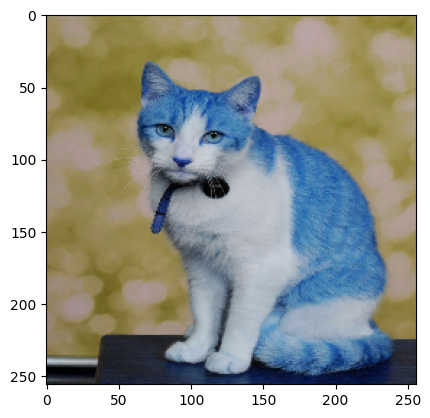

In [47]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [49]:
yhat = model.predict(np.expand_dims(resize/255, 0))
yhat

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


array([[0.7751215]], dtype=float32)

In [50]:
if yhat > 0.5: 
    print(f'Predicted class is cat')
else:
    print(f'Predicted class is dog')

Predicted class is cat
